# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

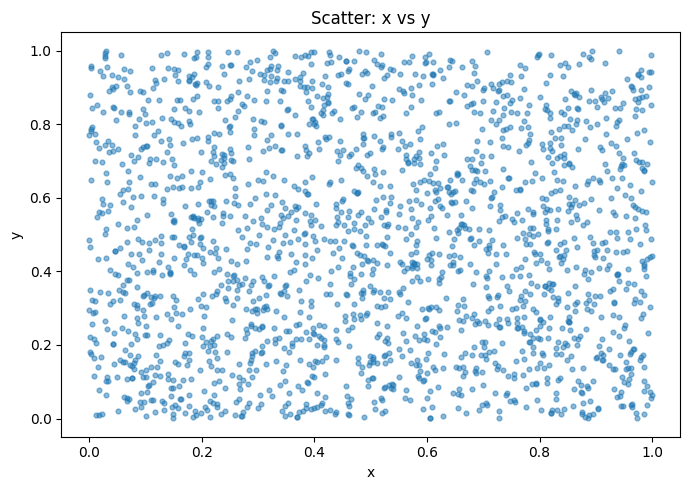

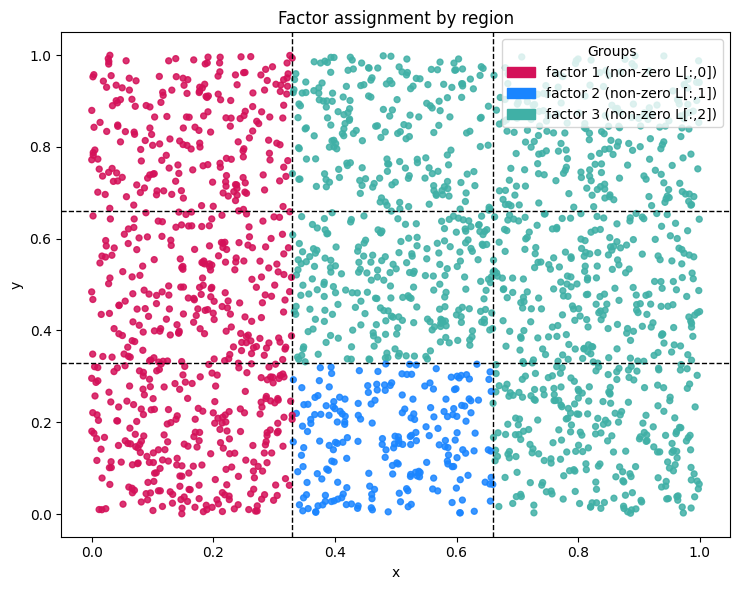

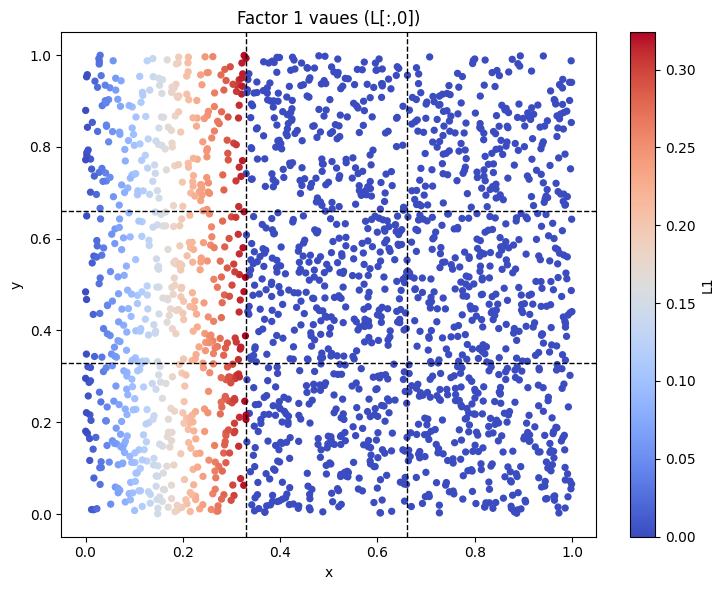

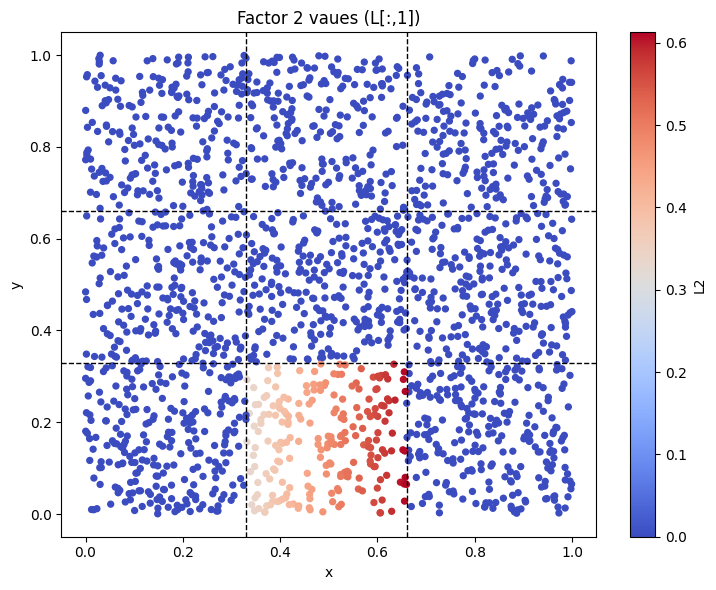

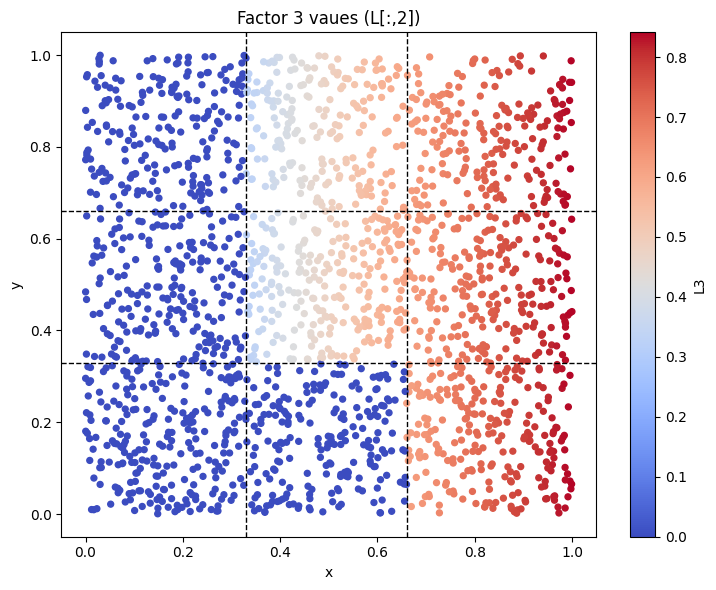

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# Config & Reproducibility
# =========================
SEED = 1
N = 2000          # number of (x,y) points
M = 200           # number of features (columns) in f
BOUNDARIES = (0.33, 0.66)  # vertical/horizontal guide lines
NOISE_STD = 1.0   # std-dev for observation noise in Z

torch.manual_seed(SEED)

# =========================
# 1) Random uniform data
# =========================
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N, 2) -- kept for clarity/optionally used later

# Quick scatter of x vs y
plt.figure(figsize=(7, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter: x vs y")
plt.tight_layout()
plt.show()

# =========================
# 2) Generate f (3 x M)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# =========================
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# =========================
# 3) Build L (N x 3) + factor labels
# =========================
L = torch.zeros(N, 3, dtype=torch.float32)

b1, b2 = BOUNDARIES
mask1 = x < b1
mask2 = (~mask1) & (x < b2) & (y < b1)  # second region
mask3 = ~(mask1 | mask2)                # everything else

# Nonzero loadings by region (note: original logic used sin(x) for all three)
L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

# Integer factor labels in {1,2,3}
factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# =========================
# 4) Factor visualization
# =========================
colors = ["#D41159", "#1A85FF", "#40B0A6"]  # red, blue, teal
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(7.5, 6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=18, alpha=0.85)
for v in (b1, b2):
    plt.axhline(v, color="black", linestyle="--", linewidth=1)
    plt.axvline(v, color="black", linestyle="--", linewidth=1)
plt.title("Factor assignment by region")
plt.xlabel("x")
plt.ylabel("y")

# Legend (explicit: red = non-zero L[:,0], etc.)
handles = [
    mpatches.Patch(color=colors[0], label="factor 1 (non-zero L[:,0])"),
    mpatches.Patch(color=colors[1], label="factor 2 (non-zero L[:,1])"),
    mpatches.Patch(color=colors[2], label="factor 3 (non-zero L[:,2])"),
]
plt.legend(handles=handles, title="Groups", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# =========================
# 5) Individual factor heatmaps (L1, L2, L3 as color)
# =========================
for i in range(3):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",  # shows magnitude of L[:,i]
        s=18
    )
    for v in (b1, b2):
        plt.axhline(v, color="black", linestyle="--", linewidth=1)
        plt.axvline(v, color="black", linestyle="--", linewidth=1)
    plt.title(f"Factor {i+1} vaues (L[:,{i}])")
    plt.xlabel("x")
    plt.ylabel("y")
    cbar = plt.colorbar()
    cbar.set_label(f"L{i+1}")
    plt.tight_layout()
    plt.show()

# =========================
# 6) Generate observations Z = L @ f + noise
# =========================
noise = NOISE_STD * torch.randn(N, M)
Z = L @ f + noise  # (N, M)

# Optional sanity checks
assert L.shape == (N, 3)
assert f.shape == (3, M)
assert Z.shape == (N, M)


We will factorize the matrix Z using 4 different models.


* EBMF using point mass Laplace without using side information
* cEBMF using a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $
* cEBMF using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0) (x,y) N(\mu, \sigma_m^2)  $
* cEBMF using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

Fitting the model without account for the 2d side information

In [2]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

tensor(-2736.1907)
6004.62109375
tensor(-3268.4304)
tensor(-2748.5396)
3726.33740234375
tensor(-977.7979)
tensor(-2801.0483)
3777.234375
tensor(-976.1860)
tensor(-2842.8206)
3386.94775390625
tensor(-544.1272)
tensor(-2844.1506)
3381.336669921875
tensor(-537.1860)
tensor(-2759.9263)
5999.48681640625
tensor(-3239.5605)
tensor(-2762.2859)
3691.16357421875
tensor(-928.8777)
tensor(-2901.8650)
3792.664794921875
tensor(-890.7998)
tensor(-3109.8567)
3454.29150390625
tensor(-344.4348)
tensor(-3104.7246)
3443.794677734375
tensor(-339.0701)
tensor(-2759.6592)
5995.11328125
tensor(-3235.4541)
tensor(-2769.7317)
3693.907470703125
tensor(-924.1758)
tensor(-2931.5081)
3812.26123046875
tensor(-880.7532)
tensor(-3256.7017)
3521.48974609375
tensor(-264.7881)
tensor(-3254.4119)
3502.373779296875
tensor(-247.9619)
tensor(-2758.0862)
5991.76513671875
tensor(-3233.6790)
tensor(-2778.1733)
3701.018798828125
tensor(-922.8455)
tensor(-2955.9448)
3833.0322265625
tensor(-877.0874)
tensor(-3374.0276)
3582.152099

CEBMFResult(L=tensor([[-6.7598e+00, -1.4332e-02,  1.8322e+00,  7.3646e-09, -1.6800e-07],
        [-1.2728e-01, -8.6281e-02,  2.0286e+00,  6.0323e-08, -6.9698e-08],
        [-1.6566e+00, -1.5823e-02, -1.1584e-02, -3.5549e-08, -4.5253e-07],
        ...,
        [-6.3495e+00, -9.7502e-01,  1.8474e-02, -1.5775e-08,  5.1910e-07],
        [-1.1016e-01,  6.2751e-02,  2.8443e+00,  7.0515e-08, -1.3485e-08],
        [-9.9256e-02,  1.2566e-01,  1.3082e+00, -2.2851e-08,  6.4656e-08]]), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4925e-02,  1.7957e-20, -9.2348e-20],
        [ 1.6497e-01,  1.4324e-01,  3.9473e-04,  6.2244e-22, -4.8140e-20],
        [-5.1115e-04, -6.7892e-04,  5.7604e-02,  1.2628e-20, -2.6080e-19],
        [-5.5547e-02,  1.2525e-01,  6.6623e-02, -6.9375e-20,  2.1519e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6553e-02, -1.1059e-19, -7.3195e-20],
        [ 1.1018e-03,  1.7563e-03, -4.5966e-04,  6.3001e-21,  1.4011e-20],
        [-1.2125e-05, -9.3930e-03, -5.1896e-04, -1.2304e-19, -1.7500e

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)
Using prior   a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $


[CASH] Epoch 10/20 | Loss: 318.4772
[CASH] Epoch 20/20 | Loss: 315.0236
tensor(-2837.6272)
5040.37744140625
tensor(-2202.7502)
[CASH] Epoch 10/20 | Loss: 205.6289
[CASH] Epoch 20/20 | Loss: 202.3860
tensor(-2892.6111)
3238.1757202148438
tensor(-345.5647)
[CASH] Epoch 10/20 | Loss: 219.3346
[CASH] Epoch 20/20 | Loss: 214.9969
tensor(-2901.5210)
3439.9496307373047
tensor(-538.4287)
[CASH] Epoch 10/20 | Loss: 209.1064
[CASH] Epoch 20/20 | Loss: 209.0528
tensor(-2826.2500)
3344.844192504883
tensor(-518.5942)
[CASH] Epoch 10/20 | Loss: 209.1635
[CASH] Epoch 20/20 | Loss: 208.8845
tensor(-2858.8059)
3342.152587890625
tensor(-483.3467)
[CASH] Epoch 10/20 | Loss: 315.7069
[CASH] Epoch 20/20 | Loss: 311.9263
tensor(-2831.6843)
4990.821304321289
tensor(-2159.1370)
[CASH] Epoch 10/20 | Loss: 203.9925
[CASH] Epoch 20/20 | Loss: 197.5661
tensor(-2839.4180)
3161.0570373535156
tensor(-321.6392)
[CASH] Epoch 10/20 | Loss: 214.2062
[CASH] Epoch 20/20 | Loss: 213.3369
tensor(-2880.7568)
3413.38981628417

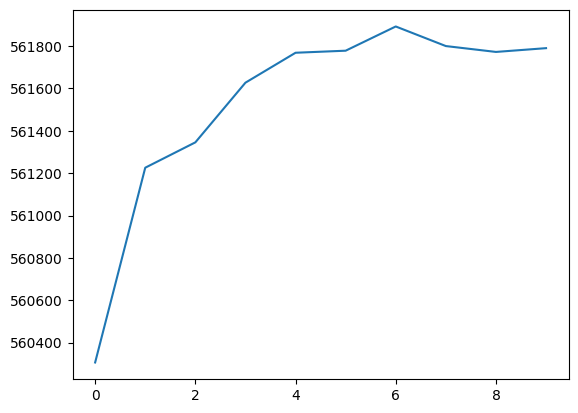

In [ ]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False) 
mycebmf11.initialise_factors()
mycebmf11.fit(10)


The ELBO is not purely monotonic for cEBMF using because the prior learning uses SGD

In [ ]:

plt.plot(mycebmf11.obj)

Fitting the cEBMF model using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0) (x,y) N(\mu, \sigma_m^2)  $
 

[CGB] Epoch 10/50, Loss=2.9964, mu2=-0.153, sigma2=6.824
[CGB] Epoch 20/50, Loss=2.9568, mu2=-0.309, sigma2=6.225
[CGB] Epoch 30/50, Loss=2.9375, mu2=-0.469, sigma2=6.432
[CGB] Epoch 40/50, Loss=2.9080, mu2=-0.631, sigma2=6.070
[CGB] Epoch 50/50, Loss=2.8941, mu2=-0.796, sigma2=5.784
tensor(-2860.4194)
4988.63818359375
tensor(-2128.2188)
[CGB] Epoch 10/50, Loss=1.7861, mu2=-0.115, sigma2=5.072
[CGB] Epoch 20/50, Loss=1.7127, mu2=-0.228, sigma2=4.961
[CGB] Epoch 30/50, Loss=1.6908, mu2=-0.355, sigma2=3.461
[CGB] Epoch 40/50, Loss=1.6888, mu2=-0.492, sigma2=4.292
[CGB] Epoch 50/50, Loss=1.6800, mu2=-0.637, sigma2=4.572
tensor(-2907.8232)
3252.137939453125
tensor(-344.3147)
[CGB] Epoch 10/50, Loss=1.9266, mu2=0.128, sigma2=2.525
[CGB] Epoch 20/50, Loss=1.8762, mu2=0.277, sigma2=2.409
[CGB] Epoch 30/50, Loss=1.8209, mu2=0.430, sigma2=2.257
[CGB] Epoch 40/50, Loss=1.8007, mu2=0.590, sigma2=1.664
[CGB] Epoch 50/50, Loss=1.7852, mu2=0.761, sigma2=1.455
tensor(-3014.8530)
3412.324462890625
ten

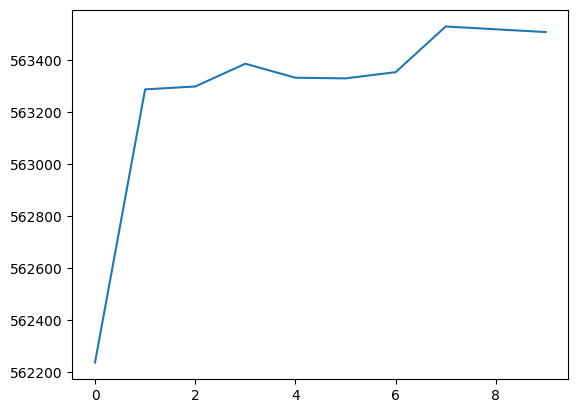

In [4]:
mycebmf12=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" , allow_backfitting=False) 
mycebmf12.initialise_factors()
mycebmf12.fit(10)

plt.plot(mycebmf12.obj)

Fitting the cEBMF model using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

In [5]:
mycebmf13=  cEBMF(data=Z, X_l=X,
                 prior_L="emdn", allow_backfitting=False) 
mycebmf13.initialise_factors()
mycebmf13.fit(10)



[EMDN] Epoch 10/50, Loss: 2.6781
[EMDN] Epoch 20/50, Loss: 2.0533
[EMDN] Epoch 30/50, Loss: 1.5863
[EMDN] Epoch 40/50, Loss: 1.5437
[EMDN] Epoch 50/50, Loss: 1.5182
tensor(-2809.3977)
3022.57080078125
tensor(-213.1731)
[EMDN] Epoch 10/50, Loss: 1.6797
[EMDN] Epoch 20/50, Loss: 1.5180
[EMDN] Epoch 30/50, Loss: 1.4993
[EMDN] Epoch 40/50, Loss: 1.4876
[EMDN] Epoch 50/50, Loss: 1.4789
tensor(-2798.8291)
2949.463623046875
tensor(-150.6345)
[EMDN] Epoch 10/50, Loss: 1.6948
[EMDN] Epoch 20/50, Loss: 1.5966
[EMDN] Epoch 30/50, Loss: 1.5207
[EMDN] Epoch 40/50, Loss: 1.4992
[EMDN] Epoch 50/50, Loss: 1.4940
tensor(-2800.1169)
2981.927978515625
tensor(-181.8110)
[EMDN] Epoch 10/50, Loss: 1.6809
[EMDN] Epoch 20/50, Loss: 1.6805
[EMDN] Epoch 30/50, Loss: 1.6801
[EMDN] Epoch 40/50, Loss: 1.6775
[EMDN] Epoch 50/50, Loss: 1.6765
tensor(-2802.3008)
3353.268310546875
tensor(-550.9675)
[EMDN] Epoch 10/50, Loss: 1.6784
[EMDN] Epoch 20/50, Loss: 1.6761
[EMDN] Epoch 30/50, Loss: 1.6730
[EMDN] Epoch 40/50, Lo

CEBMFResult(L=tensor([[-7.2345, -0.0715,  0.0143, -0.1266, -0.0731],
        [-0.2290, -0.0774,  3.2739,  0.3836, -0.4140],
        [-3.4464, -0.0839, -0.0479, -0.2313, -0.2031],
        ...,
        [-6.8211, -0.0532,  0.0306, -0.3024,  0.3122],
        [-0.0729, -0.0383,  3.2270,  0.1504,  0.7191],
        [-0.0676, -0.0273,  2.8854, -0.1649,  0.3167]]), F=tensor([[-1.2931e-01,  1.4269e-01, -9.4034e-02,  8.2909e-04, -7.4618e-04],
        [ 1.5674e-01,  1.3061e-01,  1.9595e-02, -4.8836e-04, -8.6397e-03],
        [-4.7417e-04, -5.4357e-04,  5.2350e-02,  3.9830e-04, -2.4467e-01],
        [-5.3691e-02,  1.2016e-01,  8.6002e-02, -1.0552e-03, -6.5670e-03],
        [ 4.1668e-05, -3.2468e-02,  7.3846e-02, -1.1005e-03, -3.6172e-03],
        [ 1.0784e-03,  3.4101e-03,  1.4033e-03,  7.5661e-04,  5.4977e-05],
        [ 6.3999e-05, -1.2617e-02, -4.1220e-03, -1.5020e-01,  5.0637e-03],
        [-1.8363e-01,  1.4628e-01,  3.6028e-02,  3.1355e-04,  7.3718e-04],
        [-1.1673e-04,  8.3424e-05, -9.0

we can visualized the corresponding values o the ELBO (higher the better)

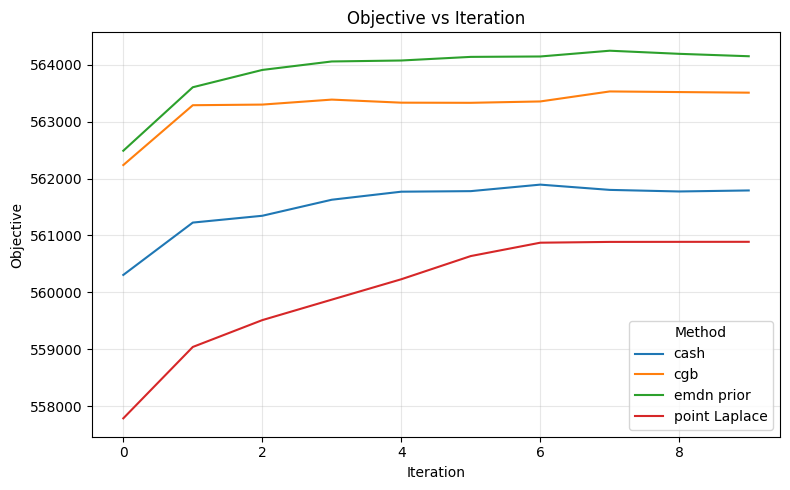

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(mycebmf11.obj), label="cash")
ax.plot(to1d(mycebmf12.obj), label="cgb")
ax.plot(to1d(mycebmf13.obj), label="emdn prior")
ax.plot(to1d(mycebmf.obj),  label="point Laplace")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The results is not surprising as in this case only the emdn prior can recover the data generating process thus leading to a better fit.


The worst is acheived by the EBMF model with point Laplace which is the least flexible model


Noe 

RMSE Point Laplace tensor(0.0087)
RMSE cash tensor(0.0065)
RMSE cgb tensor(0.0051)
RMSE emdn tensor(0.0031)


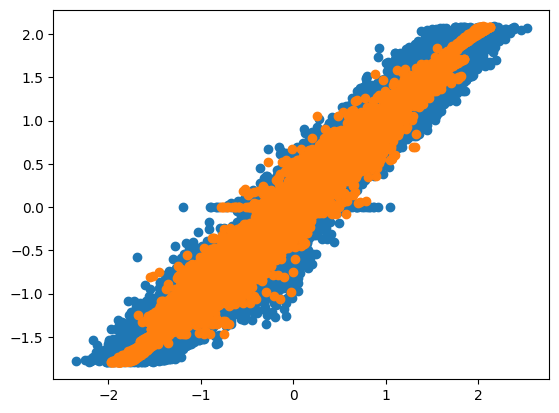

In [13]:
mycebmf._update_fitted_value()
mycebmf11._update_fitted_value()
mycebmf12._update_fitted_value()
mycebmf13._update_fitted_value()

plt.scatter(mycebmf.Y_fit,L@f)
plt.scatter(mycebmf13.Y_fit,L@f)
print("RMSE Point Laplace",torch.mean((mycebmf.Y_fit-L@f).pow(2)))

print("RMSE cash",torch.mean((mycebmf11.Y_fit-L@f).pow(2)))
print("RMSE cgb",torch.mean((mycebmf12.Y_fit-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf13.Y_fit-L@f).pow(2)))

Fitted factors (emdn prior)

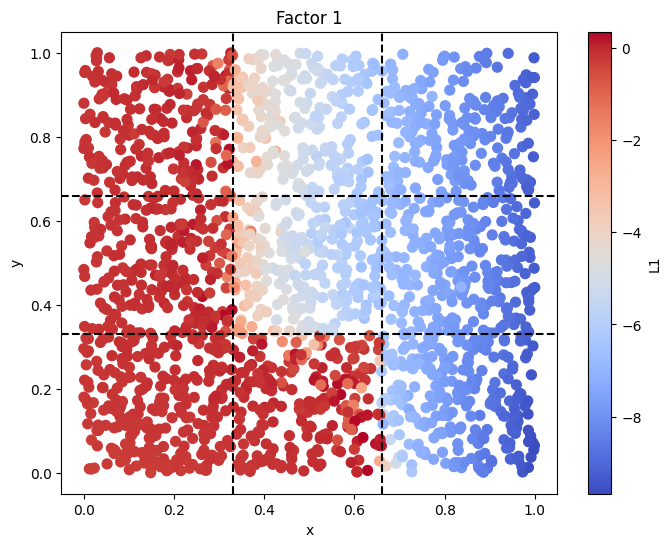

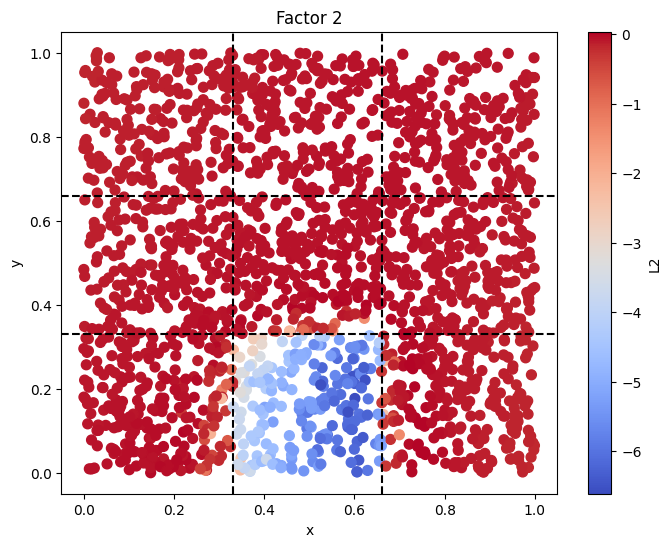

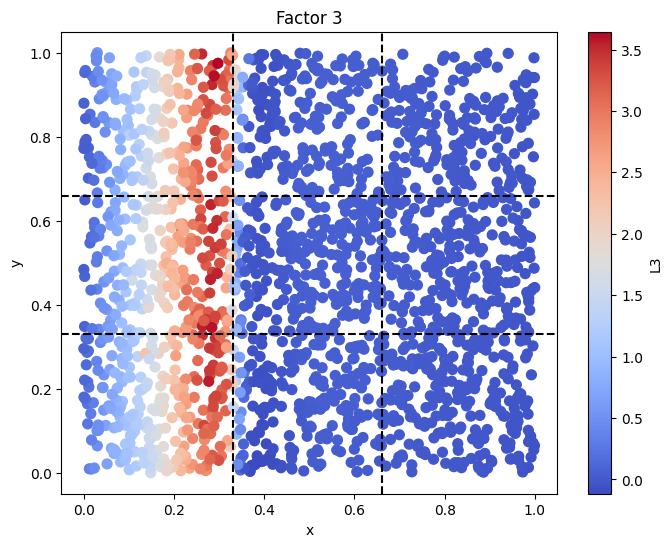

In [9]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


Fitted factors (point Laplace)

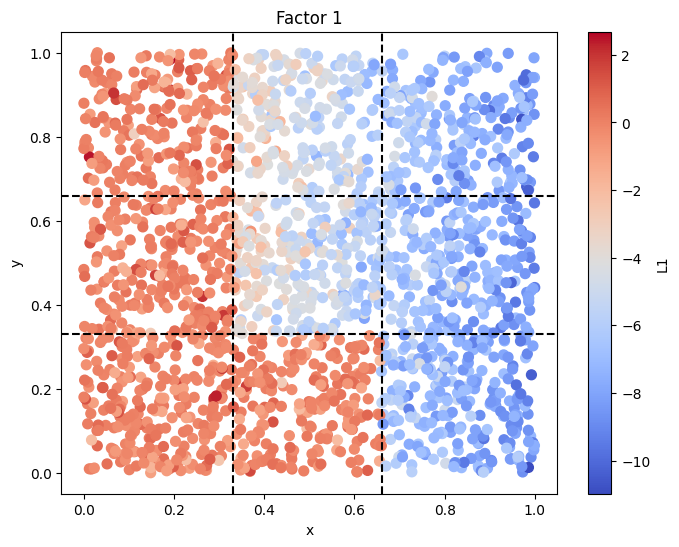

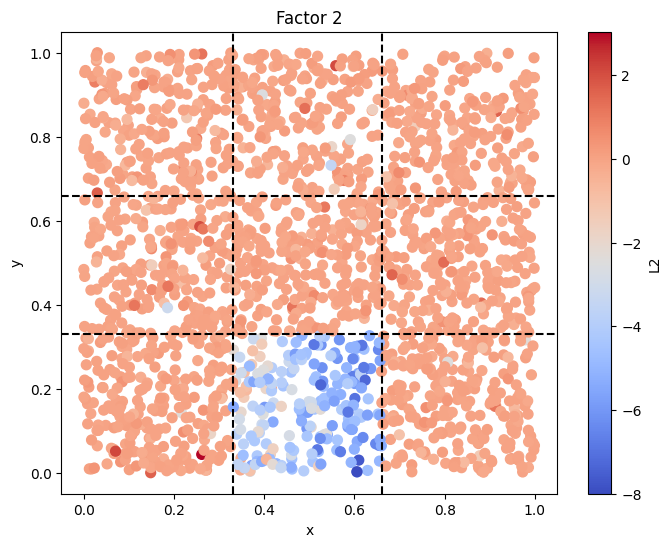

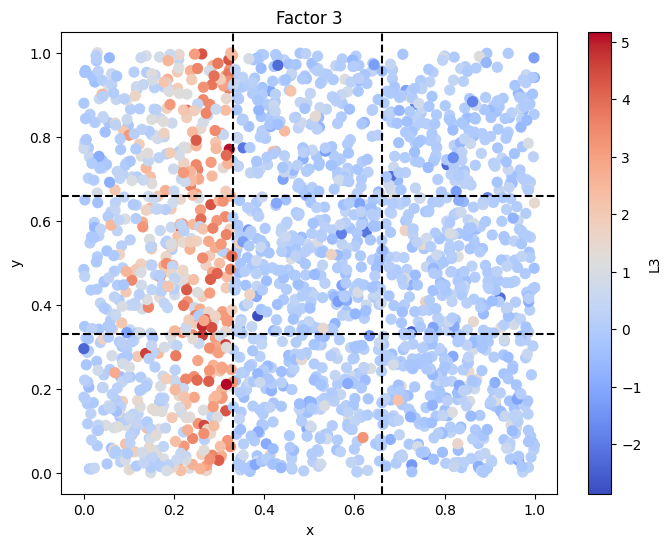

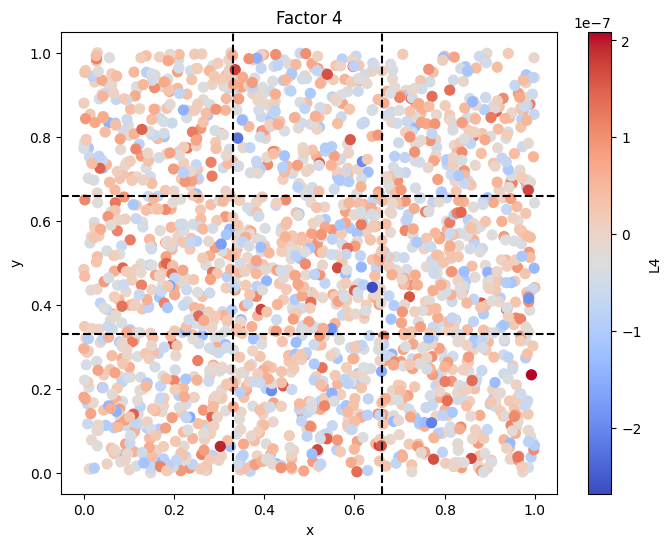

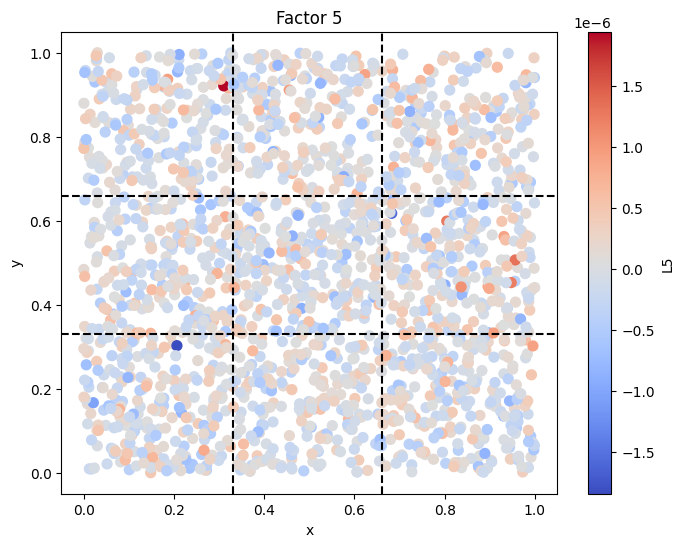

In [10]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


We can visulaized the fitted factor for the different prior 

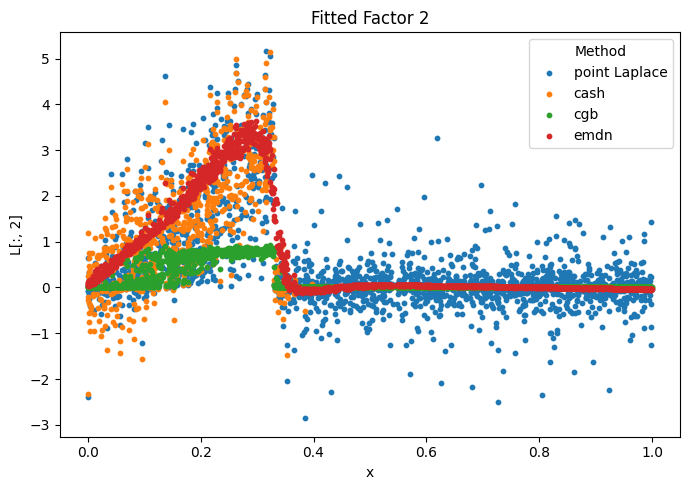

In [15]:
k = 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x.detach().cpu().numpy(), mycebmf.L[:,k].detach().cpu().numpy(), s=10, label="point Laplace")
ax.scatter(x.detach().cpu().numpy(), mycebmf11.L[:,k].detach().cpu().numpy(), s=10, label="cash")
ax.scatter(x.detach().cpu().numpy(), mycebmf12.L[:,k].detach().cpu().numpy(), s=10, label="cgb")
ax.scatter(x.detach().cpu().numpy(), mycebmf13.L[:,k].detach().cpu().numpy(), s=10, label="emdn")

ax.set_title(f"Fitted Factor {k}")
ax.set_xlabel("x"); ax.set_ylabel(f"L[:, {k}]")
ax.legend(title="Method", loc="best")
plt.tight_layout()
plt.show()
